In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import numpy as np
import geopandas as gpd
import pandas as pd
plt.rcParams.update({'mathtext.default':  'regular' })
plt.rcParams["font.family"] = "serif"
fontsize = 13

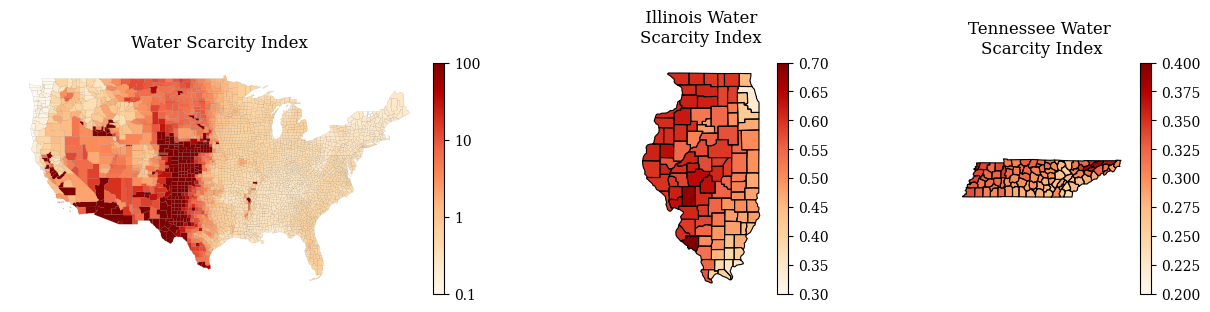

In [2]:

fig, axs = plt.subplots(1, 3, figsize=(15, 3), gridspec_kw={'wspace':0.5, 'width_ratios': [6,3,3]})
counties = gpd.read_file("../cb_2021_us_county_20m.zip")
df = pd.read_csv("../US_county_state_dataset/US_county_water_scarcity_index.csv")
df['FIPS'] = df['FIPS'].astype(str).str.zfill(5)  
counties['GEOID'] = counties['GEOID'].astype(str).str.zfill(2)
gdf = counties.merge(df, left_on='GEOID', right_on='FIPS')
gdf = gdf[~gdf['STATEFP'].isin(['02', '15', '72'])]  # AK=02, HI=15, PR=72
vmin, vmax = 0.1, 100
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
cmap = plt.cm.OrRd

tick_vals = [0.1, 1, 10, 100]
tick_labels = ['0.1', '1', '10', '100']
gdf.plot(
    column='WSI',
    cmap=cmap,
    norm=norm,
    linewidth=0.05,
    ax=axs[0],
    edgecolor='0.2',
    legend=False
)
sm = ScalarMappable(norm=norm, cmap=cmap)
sm._A = []

cbar = fig.colorbar(sm, ax=axs[0], fraction=0.03, pad=0.01, ticks=tick_vals)
cbar.ax.minorticks_off()
cbar.ax.set_yticklabels(tick_labels)

axs[0].set_title("Water Scarcity Index", fontsize=12,pad=13)
axs[0].set_axis_off()


import json

with open('../US_county_state_dataset/IL_regional_wsi.json', 'r') as f:
    il_data = json.load(f)
county_data = {geoid[-3:]: float(value) for geoid, value in il_data.items()}

with open('../US_county_state_dataset/TN_regional_wsi.json', 'r') as f:
    tn_data = json.load(f)
county_data2 = {geoid[-3:]: float(value) for geoid, value in tn_data.items()}
Fontsize = 13

illinois = counties[counties['STATEFP'] == '17']
tennessee= counties[counties['STATEFP'] == '47']
heat_data = pd.DataFrame([
    {'COUNTYFP': k, 'value': v} for k, v in county_data.items()
])
heat_data2 = pd.DataFrame([
    {'COUNTYFP': k, 'value': v} for k, v in county_data2.items()
])


illinois = illinois.merge(heat_data, on='COUNTYFP', how='left')
tennessee = tennessee.merge(heat_data2, on='COUNTYFP', how='left')

vmin, vmax = 0.3,0.7
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
illinois.boundary.plot(ax=axs[1], linewidth=0.8, color='black')

illinois.plot(column='value', ax=axs[1], norm=norm,legend=True, cmap='OrRd', missing_kwds={'color': 'lightgrey'})
axs[1].set_title(' Illinois Water \nScarcity Index', fontsize=12, pad=15)
axs[1].axis('off')

vmin, vmax = 0.2,0.4
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
tennessee.boundary.plot(ax=axs[2], linewidth=0.8, color='black')
tennessee.plot(column='value', norm=norm,ax=axs[2], legend=True, cmap='OrRd', missing_kwds={'color': 'lightgrey'})
axs[2].set_title('Tennessee Water \nScarcity Index', fontsize=12, pad=75)
axs[2].axis('off')
plt.savefig("../figures/figure10.pdf",  bbox_inches='tight')